In [1]:
import numpy as np
import torch.nn as nn
import torch
import gymnasium as gym

from torch.distributions import Categorical
import torch.nn.functional as F

In [36]:
class EmbeddingModel(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.pile_mlp = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
        )

        self.attn_mlp = nn.Sequential(
            nn.Linear(output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, pile_obs):
        # pile_obs: (B, 52, 2)

        card_feats = self.pile_mlp(pile_obs)      # (B, 52, H)
        scores = self.attn_mlp(card_feats)        # (B, 52, 1)
        weights = torch.softmax(scores, dim=1)    # (B, 52, 1)

        pile_summary = (card_feats * weights).sum(dim=1)  # (B, H)
        return pile_summary, weights
    
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=64, has_encoder=False):
        super().__init__()
        self.has_encoder = has_encoder
        if has_encoder:
            obs_dim += hidden_dim  # Concatenate encoder output to obs

        self.actor = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, act_dim),
        )

        self.critic = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.encoder = EmbeddingModel(output_dim=hidden_dim)

    def forward(self, obs, claims=None):
        if self.has_encoder and claims is not None:
            pile_summary, _ = self.encoder(claims)
            obs = torch.cat([obs, pile_summary], dim=-1)
        logits = self.actor(obs)
        value = self.critic(obs)
        return logits, value

    def get_action(self, obs, action_mask, claims=None):
        if self.has_encoder and claims is not None:
            pile_summary, _ = self.encoder(claims)
            obs = torch.cat([obs, pile_summary], dim=-1)
        logits = self.actor(obs)
        logits = logits.masked_fill(action_mask == 0, float("-inf"))
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, logits

In [37]:
model = ActorCritic(obs_dim=22, act_dim=19)
model.load_state_dict(torch.load("../ppo_model_100_32.pth", weights_only=True))
model.eval()

ActorCritic(
  (actor): Sequential(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=19, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
  (encoder): EmbeddingModel(
    (pile_mlp): Sequential(
      (0): Linear(in_features=2, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
    )
    (attn_mlp): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)

In [38]:
import sys
from pathlib import Path

# Ensure parent project folder is importable in this notebook kernel
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
	sys.path.append(str(project_root))

from core.environment import Environment
from core.configs import EnvironmentConfig


In [39]:
torch.manual_seed(505)

cfg = EnvironmentConfig(num_agents=2, SEE_CARD_COUNTS=True)
env = Environment(cfg)

In [40]:
observations, info = env.reset()
observations

{'observation': tensor([1.0000, 0.0000, 0.0000, 0.7500, 0.7500, 0.7500, 0.2500, 0.2500, 0.5000,
         0.5000, 0.0000, 0.5000, 0.5000, 0.7500, 0.5000, 0.5000, 0.0000, 0.0769,
         0.0000, 0.0000, 0.5000, 0.5000]),
 'action_mask': tensor([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'claim_seq': tensor([[0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],


In [41]:
state = observations["observation"]
action_mask = observations["action_mask"]
claim_sequence = observations["claim_seq"]

In [42]:
with torch.no_grad():
    action, log_ps, logits = model.get_action(torch.tensor(state, dtype=torch.float32), torch.tensor(action_mask, dtype=torch.bool), torch.tensor(claim_sequence, dtype=torch.float32))
action, log_ps, logits

/var/folders/fs/fq3rc5cx4290klwlf5z7r0dc0000gn/T/ipykernel_79710/3441584653.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action, log_ps, logits = model.get_action(torch.tensor(state, dtype=torch.float32), torch.tensor(action_mask, dtype=torch.bool), torch.tensor(claim_sequence, dtype=torch.float32))


(tensor(0),
 tensor(-1.6408),
 tensor([-0.1944,  0.4481, -0.2284,  0.0616,    -inf,    -inf,    -inf,    -inf,
            -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf,    -inf,    -inf]))

In [43]:
dist = torch.distributions.Categorical(logits=logits)
print(dist.probs)
print(action)
print(dist.log_prob(action))

tensor([0.1938, 0.3685, 0.1873, 0.2504, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])
tensor(0)
tensor(-1.6408)


In [4]:
training_metadata = torch.load("/Users/derekzhu/Code/BSRL/ppo/ppo_training_metadata.pth", weights_only=True)
training_metadata.keys()

dict_keys(['losses', 'policy_losses', 'value_losses', 'entropies', 'epoch_mean_rewards', 'epoch_mean_policy_loss', 'epoch_mean_value_loss'])

In [2]:
import matplotlib.pyplot as plt

### Per-Epoch Curves: Policy Loss, Value Loss, Mean Return

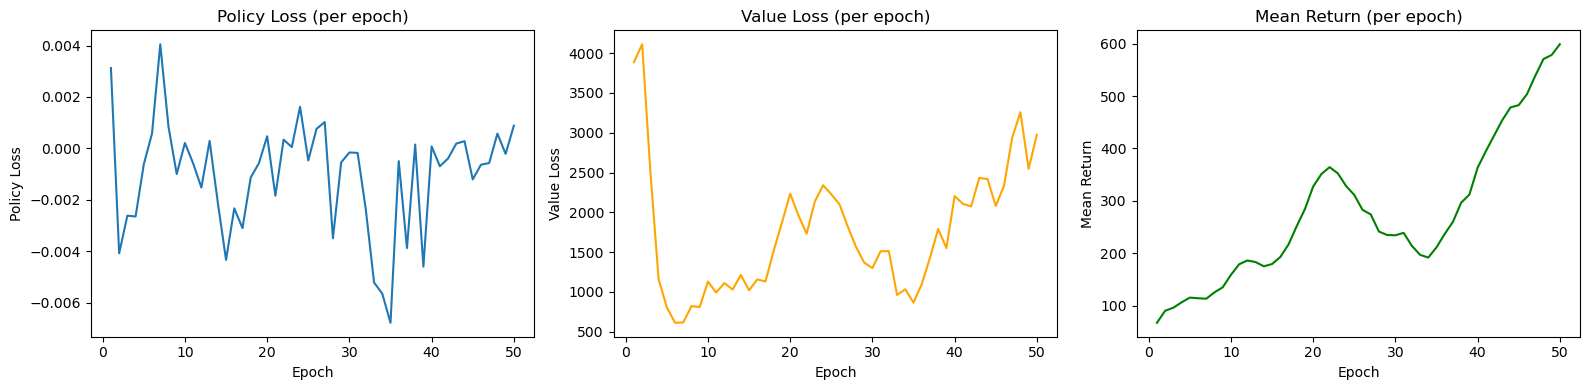

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs = range(1, len(training_metadata["epoch_mean_policy_loss"]) + 1)

axes[0].plot(epochs, training_metadata["epoch_mean_policy_loss"])
axes[0].set_title("Policy Loss (per epoch)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Policy Loss")

axes[1].plot(epochs, training_metadata["epoch_mean_value_loss"], color="orange")
axes[1].set_title("Value Loss (per epoch)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value Loss")

axes[2].plot(epochs, training_metadata["epoch_mean_rewards"], color="green")
axes[2].set_title("Mean Return (per epoch)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean Return")

plt.tight_layout()
plt.show()

### Per-Batch Curves: Policy Loss, Value Loss, Entropy

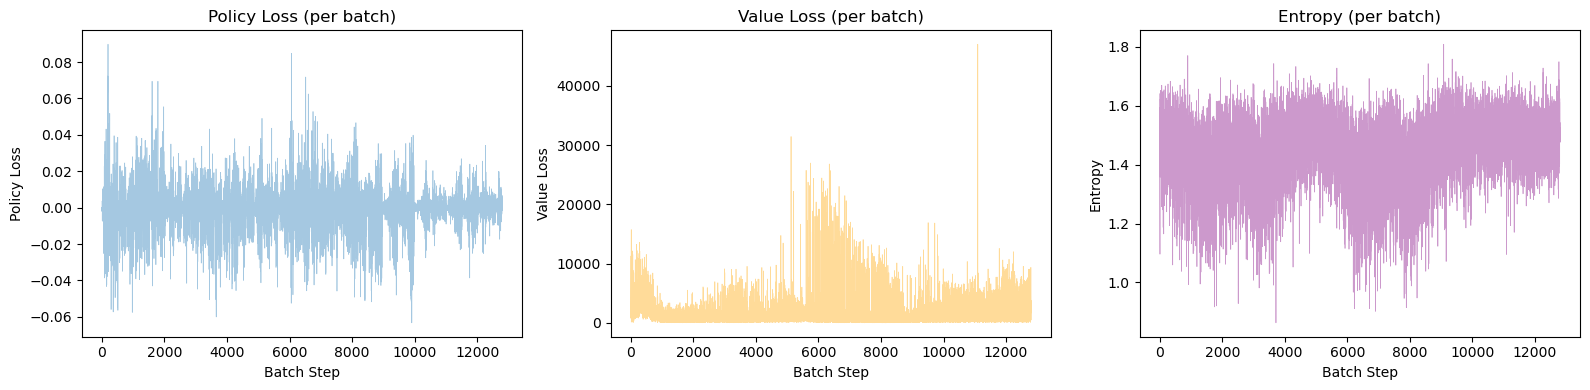

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

steps = range(1, len(training_metadata["policy_losses"]) + 1)

axes[0].plot(steps, training_metadata["policy_losses"], alpha=0.4, linewidth=0.5)
axes[0].set_title("Policy Loss (per batch)")
axes[0].set_xlabel("Batch Step")
axes[0].set_ylabel("Policy Loss")

axes[1].plot(steps, training_metadata["value_losses"], alpha=0.4, linewidth=0.5, color="orange")
axes[1].set_title("Value Loss (per batch)")
axes[1].set_xlabel("Batch Step")
axes[1].set_ylabel("Value Loss")

axes[2].plot(steps, training_metadata["entropies"], alpha=0.4, linewidth=0.5, color="purple")
axes[2].set_title("Entropy (per batch)")
axes[2].set_xlabel("Batch Step")
axes[2].set_ylabel("Entropy")

plt.tight_layout()
plt.show()

### Combined Total Loss (per batch)

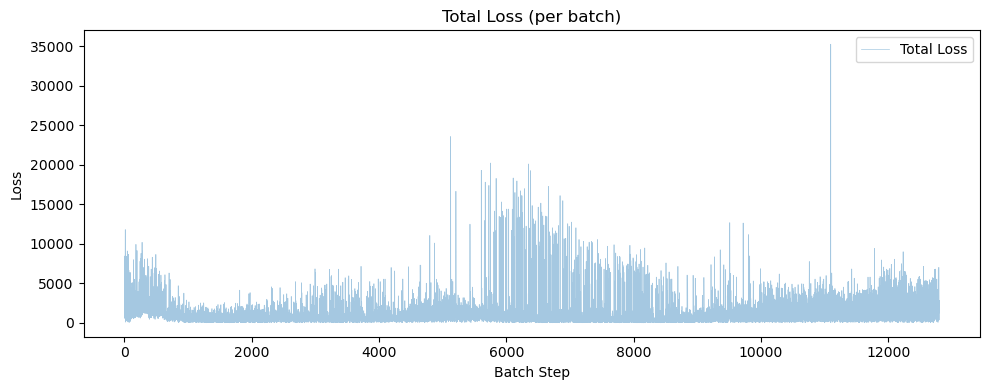

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(training_metadata["losses"], alpha=0.4, linewidth=0.5, label="Total Loss")
plt.title("Total Loss (per batch)")
plt.xlabel("Batch Step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()